<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="CORRELATION_CROP_BANNER.jpg"  style="display: block; margin-left: auto; margin:0px auto;";/>
</div>

## Modeling the Impact of Environmental and Weather Factors on Standardized Crop Yield
© Mike Bwisa M.

# Primary Objective
- To build and evaluate a Multiple Linear Regression model that accurately predicts the standardized crop yield (Standard_yield) based on environmental, geographic, and weather-driven features.

# Project Objectives

## 1. Specific Objectives
- Quantify Weather Impacts: Determine the specific extent to which variation in weather elements (such as average temperature and rainfall) influences overall field productivity.

- Assess Geographic and Soil Features: Analyze the relationship between a field's physical baseline characteristics (elevation, slope, and soil fertility) and its standardized yield.

- Evaluate Environmental Stressors: Isolate and measure the negative impact of external environmental constraints (such as local Pollution_level) on crop output.

- Feature Selection & Optimization: Identify which subset of environmental factors holds the highest predictive power, allowing for a more streamlined, optimized model.

## 2. Statistical & Diagnostic Objectives

- Validate Classical Linear Regression Assumptions:

Ensure model reliability by testing for linearity, homoscedasticity, normality of residuals, and identifying/mitigating multicollinearity (especially among temperature variables like Ave_temps, Min_temperature_C, and Max_temperature_C).

- Interpret Coefficients for Actionable Insights:

Utilize the model's coefficients to provide data-driven recommendations on which natural factors are the strongest catalysts or detractors for farm performance across the region.

# 3. Technologies & Tools Used
### 1. **Core Environment & Language**
- Python:

The primary programming language used for data engineering, statistical computation, and predictive modeling.
  
- Jupyter Notebooks:

The interactive development environment (IDE) utilized for step-by-step data exploration, visualization rendering, and documenting the model lifecycle.
  
### 2. **Data Manipulation & Preprocessing**

- Pandas:
  
Used for structured data manipulation, handling missing values, filtering features based on the data dictionary, and performing one-hot encoding on categorical variables.
  
- NumPy:

Employed for high-performance vectorized numerical operations and mathematical transformations.

### 3. **Statistical Modeling & Machine Learning**
   
- Statsmodels:

Utilized to build the Ordinary Least Squares (OLS) regression model, check detailed regression diagnostics, evaluate $p$-values, and test for statistical assumptions (like homoscedasticity and normality of residuals).

- Scikit-Learn (sklearn):

Used for splitting the dataset into training and testing sets (train_test_split) and evaluating predictive performance metrics like Root Mean Squared Error (RMSE) and $R^2$.

### 4. **Data Visualization**
   
- Matplotlib:

The foundational library used to customize and render baseline plots, distributions, and individual regression lines.

- Seaborn:

Built on top of Matplotlib, used to generate high-level statistical graphics such as the multicollinearity correlation heatmap and residual diagnostic plots.

# Initial data exploration
- Simple linear regression is a fundamental statistical method used to quantify the relationship between two variables. It allows the predict an outcome (dependent variable) based on the value of one predictor (independent variable).
- I will apply simple linear regression to understand how different environmental factors affect the standardised yield of crops.
- The insights will not only help local farmers maximise their harvests but also contribute to the sustainable agriculture practices
  
## Data exploration
- Before we sow the seeds of the regression model, we need to get to know our soil – the dataset. This dataset was developed through extensive agricultural surveys conducted at farms. It contains various factors that might influence a farm's crop yield, from the elevation of the fields to the average temperature they bask in.

# Data dictionary

**1. Geographic features**

- **Field_ID:** A unique identifier for each field (BigInt).
 
- **Elevation:** The elevation of the field above sea level in metres (Float).

- **Latitude:** Geographical latitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Longitude:** Geographical longitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Location:** Province the field is in (Text).

- **Slope:** The slope of the land in the field (Float).

**2. Weather features**

- **Rainfall:** Amount of rainfall in the area in mm (Float).

- **Min_temperature_C:** Average minimum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Max_temperature_C:** Average maximum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Ave_temps:** Average temperature in Celcius (Float).

**3. Soil and crop features**

- **Soil_fertility:** A measure of soil fertility where 0 is infertile soil, and 1 is very fertile soil (Float).

- **Soil_type:** Type of soil present in the field (Text).

- **pH:** pH level of the soil, which is a measure of how acidic/basic the soil is (Float).

**4. Farm management features**

- **Field_ID:** Corresponding field identifier (BigInt).

- **Pollution_level:** Level of pollution in the area where 0 is unpolluted and 1 is very polluted (Float).

- **Plot_size:** Size of the plot in the field (Ha) (Float). (DUMMY VARIABLE)

- **Chosen_crop:** Type of crop chosen for cultivation (Text).

- **Annual_yield:** Annual yield from the field (Float). This is the total output of the field. The field size and type of crop will affect the Annual Yield (DUMMY VARIABLE - Removed)

<br>

**5. Target variable**
- **Standard_yield:** Standardised yield expected from the field, normalised per crop (Float). This is independent of field size, or crop type. Multiplying this number by the field size, and average crop yield will give the Annual_Yield.

---

## 2. Data Loading & Library Importation
- First, we need to import the essential libraries for data manipulation, visualization, and statistical modeling, then load the dataset.
- Let's import our database.

**Important:** The `data_ingestion.py` file and the `field_data_processor.py` files are stored in the same folder in this notebook.

In [2]:
# Read the database, and clean the data using the processing modules we built.

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_data_processor import WeatherDataProcessor
import logging 

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """,
    "db_path": 'sqlite:///Farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns" : {
            'Rainfall': r'(\d+(\.\d+)?)\s?mm',
            'Temperature': r'(\d+(\.\d+)?)\s?C',
            'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
            },
}
# Ignoring the field data for now.
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# weather_processor = WeatherDataProcessor(config_params)
# weather_processor.process()
# weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2026-06-04 10:59:41,689 - data_ingestion - INFO - Database engine created successfully.
2026-06-04 10:59:41,915 - data_ingestion - INFO - Query executed successfully.
2026-06-04 10:59:41,916 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2026-06-04 10:59:41,922 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-06-04 10:59:44,369 - data_ingestion - INFO - CSV file read successfully from the web.


In [ ]:
dataset

Before diving into our analysis, it's crucial to ensure the integrity of our dataset and that the data are still as we expect it to be.

In [3]:
# Validate the data
# !pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)

!pytest validate_data.py -v

import os# Define the file paths
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

============================= test session starts ==============================
platform darwin -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
rootdir: /Users/mikebwisa/ML_machine_learning/Linear regression [Modeling the Impact of Environmental and Weather Factors on Standardized Crop Yield]
plugins: anyio-4.7.0
collected 4 items                                                              

validate_data.py::test_read_field_dataframe_shape PASSED                 [ 25%]
validate_data.py::test_field_dataframe_columns PASSED                    [ 50%]
validate_data.py::test_field_dataframe_non_negative_elevation PASSED     [ 75%]
validate_data.py::test_crop_types_are_valid PASSED                       [100%]

============================== 4 passed in 1.42s ===============================
Deleted sampled_field_df.csv


# 3. Analysis
## Linearity Check (Scatter Plots)
Linear regression assumes a linear relationship between the independent variables and the target. Let's plot Standard_yield against key weather and environmental factors.

## Visualising the relationship

With our data ready and loaded, it's time to start exploring.

The goal is to determine whether any of the features in our dataset are influencing the Standard_yield of a farm. If we can figure out what these relationships are, then we can use them to start predicting what future yields will be, based on these features.

For this analysis, we want to find whether any features have a linear relationship with Standard_yield so that we can fit a linear regression model to the data. This is important because if we try and fit a linear regression model to non-linear data, our predictions won't be good.

Any of the features could have an impact on the Standard_yield. Let's begin with Ave_temps, the average temperature of the region, and its relationship to Standard_yield.

Let's start with the basics: a scatter plot.


**⚙️Task:**

 1. Generate a scatter plot to visualise the relationship between `Ave_temps` and `Standard_yield`.
 2. Reflect on the scatter plot. Does it suggest a linear relationship, or is the story more complex?

**Note:**
- Used `matplotlib` to create the scatter plot.

In [5]:
import matplotlib.pyplot as plt

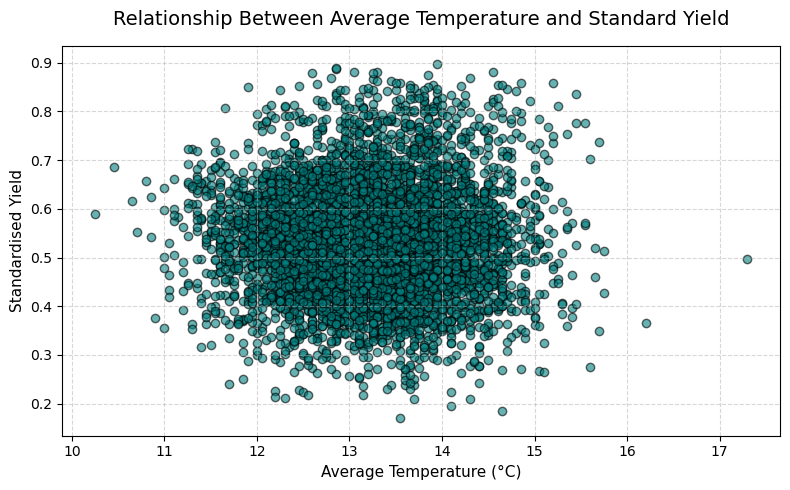

In [6]:
# Generating the scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(dataset['Ave_temps'], dataset['Standard_yield'], color='teal', alpha=0.6, edgecolor='k')

plt.title('Relationship Between Average Temperature and Standard Yield', fontsize=14, pad=15)
plt.xlabel('Average Temperature (°C)', fontsize=11)
plt.ylabel('Standardised Yield', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Now, let's write a function to calculate the Pearson correlation coefficient.

**⚙️ Task:**

Create a function named `get_correlation` that:
1. Takes a DataFrame and the names of the columns we want to determine the correlation for as parameters (`Ave_temps` and `Standard_yield`).
2. Calculates the Pearson correlation coefficient between these two columns to quantify their linear relationship.
4. Returns the Pearson correlation coefficient.

**Note:**
- Use `scipy` to calculate the Pearson correlation coefficient.
- Ensure your function returns the Pearson correlation coefficient as a float.

In [26]:
from scipy.stats import pearsonr

In [27]:
### START FUNCTION    
def get_correlation(df, col1, col2):
    """
    Calculates the Pearson correlation coefficient between two columns in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    col1 (str): The name of the first column (e.g., 'Ave_temps').
    col2 (str): The name of the second column (e.g., 'Standard_yield').
    
    Returns:
    float: The Pearson correlation coefficient.
    """
    # scipy.stats.pearsonr returns a tuple: (correlation_coefficient, p_value)
    correlation_coefficient, _ = pearsonr(df[col1], df[col2])
    
    # Ensure the returned value is explicitly a float
    return float(correlation_coefficient)

# Example usage with your 'dataset' DataFrame:
# r_value = get_correlation(dataset, 'Ave_temps', 'Standard_yield')
# print(f"Pearson correlation coefficient: {r_value:.4f}")
### END FUNCTION

Input:

In [15]:
correlation = get_correlation(dataset,'Ave_temps','Standard_yield')
print("Pearson correlation coefficient:", correlation)

Pearson correlation coefficient: 0.006785950289020191


What we notice about the scatter plot and the dispersion of data points? It's essential to visualise our data first; if the data doesn't follow a linear pattern, then a linear regression model may fail to accurately capture the underlying relationship. The correlation also seems extremely low. What does this tell us?

## Observations:

✍️
  - The Pearson correlation coefficient ($r$) measures the strength and direction of a linear relationship on a scale from -1 to 1.
  - Given your previous observation that the relationship between Ave_temps and Standard_yield follows a non-linear, inverted U-shape, you should expect this function to return a very low or near-zero correlation coefficient.
  - This happens because the positive linear trend on the left side of the curve cancels out the negative linear trend on the right side, highlighting why visual exploration with scatter plots is always vital before relying on summary statistics alone!

## Correlation: A breath of fresh data – Pollution as a predictor


It's time to shift our gaze from the warmth of the sun to the haze of pollution. Could the levels of pollution, a concern for farmers and environmentalists alike, be an indicator of our yields?

Let's begin by fitting a simple linear regression model to try and capture the linear relationship between these columns.

**⚙️ Task:**

Create a function named `fit_linear_regression_model` that:
1. Takes in a DataFrame and the names of the `Pollution_level` and `Standard_yield` columns.
2. Fits a linear regression model to the data.
3. Returns the model, the model predictions, and the actual y-values.

**Note:**
- Use `LinearRegression` from `sklearn` to fit the model.

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
### START FUNCTION
def fit_linear_regression_model(df, pollution_col, yield_col):

    """
    Fits a simple linear regression model using sklearn to capture the linear 
    relationship between pollution levels and standardized crop yield.
    
    Parameters:
    df (pd.DataFrame): The dataset containing the farm features.
    pollution_col (str): The column name for the independent variable ('Pollution_level').
    yield_col (str): The column name for the dependent target variable ('Standard_yield').
    
    Returns:
    model: The fitted scikit-learn LinearRegression object.
    predictions (np.ndarray): Predicted yield values generated by the model.
    y_actual (pd.Series): The actual yield values from the dataset.
    """
    # 1. Extract features and target. 
    # sklearn requires the feature matrix X to be 2D, so we use double brackets [[...]]
    X = df[[pollution_col]]
    y_actual = df[yield_col]
    
    # 2. Instantiate the linear regression model
    model = LinearRegression()
    
    # 3. Fit the model to the data
    model.fit(X, y_actual)
    
    # 4. Generate model predictions
    predictions = model.predict(X)
    
    return model, predictions, y_actual

# Example usage:
# model, y_pred, y_true = fit_linear_regression_model(dataset, 'Pollution_level', 'Standard_yield')
### END FUNCTION

Input:

In [35]:
model, predictions, y_values = fit_linear_regression_model(dataset, 'Pollution_level', 'Standard_yield')
print(f"Model: {model}")
print(f"Predictions: {predictions}")
print(f"Actual Y-Values: {y_values}")

Model: LinearRegression()
Predictions: [0.5540956  0.50920888 0.51515565 ... 0.56626844 0.56626844 0.52896886]
Actual Y-Values: 0       0.577964
1       0.486302
2       0.649647
3       0.532348
4       0.555076
          ...   
5649    0.554482
5650    0.438194
5651    0.800776
5652    0.507595
5653    0.453064
Name: Standard_yield, Length: 5654, dtype: float64


Expected output:
```
- Model: an instance of the LinearRegression class.
- Predictions: a NumPy array of predicted values.
- y: a Pandas Series with the actual target values used for training.
```

Linear regression models only work well if our data are in fact linear. So, let's create a scatter plot to visualise the relationship between pollution and crop yields. In addition to this, let's use the predictions from the model we fit to add the line of best fit to our scatter plot.

**⚙️ Task:**

1. Generate a scatter plot to visualise the effect that pollution has on standard yield.
2. Draw the line of best fit.

**Hint:**

You can use this line of code to draw the regression line on the plot:
`plt.plot(X, predictions, color='red', label='Regression line')`

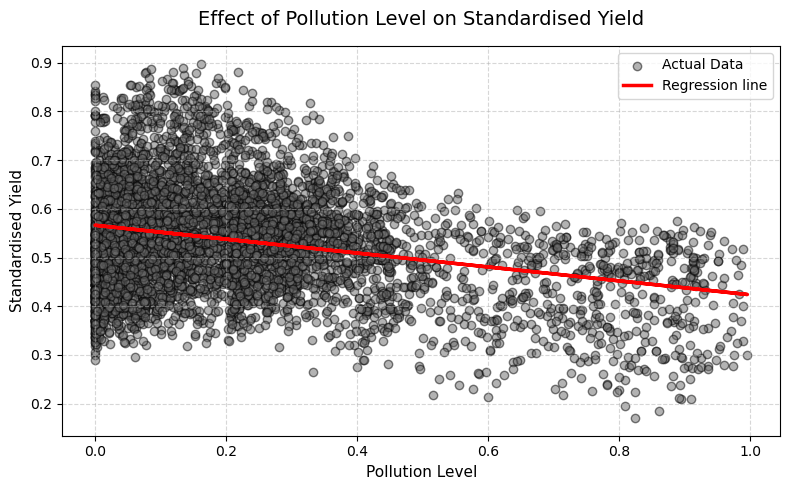

In [36]:
X = dataset[['Pollution_level']]
y = dataset['Standard_yield']

# 2. Set up the plotting window size
plt.figure(figsize=(8, 5))

# 3. Create the scatter plot for the actual data points
plt.scatter(X, y, color='dimgray', alpha=0.5, label='Actual Data', edgecolor='k')

# 4. Draw the regression line (Line of Best Fit)
# Make sure 'predictions' holds the output array from your fit_linear_regression_model function
plt.plot(X, predictions, color='red', linewidth=2.5, label='Regression line')

# 5. Add titles, axis labels, and a legend
plt.title('Effect of Pollution Level on Standardised Yield', fontsize=14, pad=15)
plt.xlabel('Pollution Level', fontsize=11)
plt.ylabel('Standardised Yield', fontsize=11)
plt.legend()

# 6. Add a subtle grid for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# 7. Display the plot cleanly
plt.tight_layout()
plt.show()

Now, use the get_correlation() function that we defined earlier to test the correlation between `Pollution_level` and `Standard_yield`.

In [37]:
Pollution_correlation = get_correlation(dataset,'Pollution_level','Standard_yield')
print("Pearson correlation coefficient:", Pollution_correlation)

Pearson correlation coefficient: -0.2857609646210545


Reflect on the difference between this plot and correlation and the previous one with the average temperature. Is the relationship between pollution and yield more linear?

✍️ 
Pollution is more linear. The relationship between Pollution_level and Standard_yield is significantly more linear than the relationship with temperature.

The Temperature Plot: Formed a complex, curved, inverted U-shape. Because it went up and then came back down, a straight line couldn't capture the trend at all.

The Pollution Plot: Shows a steady, monotonic downward trend across the entire spectrum. As pollution increases from 0 to 1, yields consistently tend to drop. There are no sudden bends or reversals in the data pattern, making it a much better fit for a standard straight-line linear regression model.

Ave_temps has a strong, non-linear (curved) relationship with yield. Pearson correlation fails to capture it.

Pollution_level has a weak-to-moderate, truly linear relationship with yield. A simple linear regression model can safely be used here, but it only explains a small portion of the overall yield puzzle. We will need a multiple linear regression model that combines both weather and environmental features to make truly accurate predictions!


We can also gain a better understanding of our model by examining the slope and intercept.

**⚙️ Task:**

Create a function named `get_slope_intercept` that:
1. Inputs the `model` we fitted and calculates the slope and intercept of the line of best fit.
2. Returns the slope and intercept as a tuple.


In [38]:
### START FUNCTION
def get_slope_intercept(model):

    """
    Extracts the slope and intercept from a fitted scikit-learn LinearRegression model.
    
    Parameters:
    model: A fitted scikit-learn LinearRegression model object.
    
    Returns:
    tuple: A tuple containing (slope, intercept) as floats.
    """
    # model.coef_ is an array of coefficients. For simple linear regression, 
    # we take the first element [0] to get the slope as a scalar float.
    slope = float(model.coef_[0])
    
    # model.intercept_ is already a scalar float
    intercept = float(model.intercept_)
    
    return slope, intercept

### END FUNCTION

Input:

In [39]:
slope, intercept = get_slope_intercept(model)
print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.1427617720986607
Intercept: 0.566268441539338



What does the slope tell us about the strength of the relationship between pollution and yield? Also, what can we learn from the y-intercept?

✍️
The Slope (-0.1428)
  - The slope tells us the direction and magnitude (rate of change) of the relationship.
  - The Direction: Because the slope is negative, it confirms an inverse relationship. As pollution increases, crop yield decreases.
  - The Meaning: For every 1-unit increase in the Pollution_level (which is the maximum jump on a scale from 0 to 1), the Standard_yield is expected to drop by approximately 0.1428 units.

The Y-Intercept (0.5663)
 - The y-intercept represents the baseline starting point where the regression line crosses the vertical axis (where X = 0).
 - In practical terms, this is the expected Standard_yield of a farm that has a Pollution_level of exactly 0 (a perfectly pristine, unpolluted environment).
 - The Baseline: It gives us a crucial benchmark. It tells us that without the negative drag of environmental pollution, the baseline expected standardized yield for these crops is about 0.5663.
 - As pollution creeps into the area, the model begins chipping away from this maximum baseline value using the slope.

## 3: The haze clears: Evaluating pollution's predictive power

When we look at the scatterplots of `Standard_yield` with `Ave_temps` and `Pollution_level`, it appears that pollution level might have a more linear relationship.  This means that we could potentially use a simple linear regression model to make predictions about the yield of a farm based on its pollution level. However, before we do this we need to further assess the strength of the linear relationship between `Pollution_level` and `Standard_yield`. 

Let's assess our model's performance using R-squared, mean absolute error (MAE), mean squared error (MSE), and root mean squared error (RMSE).

**⚙️ Your task:**

Create a function named `calculate_evaluation_metrics` that:
1. Takes the predictions and y-values from our fitted model as input.
2. Calculates and returns the R-squared, mean absolute error (MAE), mean squared error (MSE), and root mean squared error (RMSE) of the model's performance.

**Note:**
1. Calculate the model's performance metrics using the entire dataset.
2. Return the evaluation metrics as a tuple in the order: R-squared, MAE, MSE, RMSE.

In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [45]:
### START FUNCTION
def calculate_evaluation_metrics(predictions, y_values):
    """
    Calculates key regression evaluation metrics to evaluate model performance.
    
    Parameters:
    predictions (np.ndarray): The predicted target values from the model.
    y_values (pd.Series or np.ndarray): The actual target values from the dataset.
    
    Returns:
    tuple: A tuple containing (R-squared, MAE, MSE, RMSE) as floats.
    """
    # 1. Calculate R-squared (Coefficient of Determination)
    r2 = float(r2_score(y_values, predictions))
    
    # 2. Calculate Mean Absolute Error
    mae = float(mean_absolute_error(y_values, predictions))
    
    # 3. Calculate Mean Squared Error
    mse = float(mean_squared_error(y_values, predictions))
    
    # 4. Calculate Root Mean Squared Error
    rmse = float(np.sqrt(mse))
    
    return r2, mae, mse, rmse

### END FUNCTION

Input:

In [46]:
evaluation_metrics = calculate_evaluation_metrics(predictions, y_values)
print(f"Evaluation Metrics:\nR-squared: {evaluation_metrics[0]}\nMAE: {evaluation_metrics[1]}\nMSE: {evaluation_metrics[2]}\nRMSE: {evaluation_metrics[3]}")

Evaluation Metrics:
R-squared: 0.08165932890115568
MAE: 0.08554642090904993
MSE: 0.011477732254034844
RMSE: 0.10713417873878926


Think about what these metrics tell us about our model's accuracy and reliability. Write down your observations:

✍️
The R-squared Value (0.0817): High UnreliabilityThe R^2 score is the most telling metric here.
  - An R^2 of 0.0817 means that pollution levels account for only about 8.2% of the variance in standardized crop yields.
  - The Takeaway: The remaining 91.8% of the variation in crop yield is completely unexplained by this model.Reliability: This tells us that using only pollution to predict yield is highly unreliable.
  - If a farmer asks you to estimate their harvest based solely on how hazy the air is, your prediction is barely going to be better than a blind guess based on the historical average.
    
The Error Metrics (MAE & RMSE):
 - Deceptively Small ErrorsAt first glance, your error metrics look fantastic because they are so close to zero:MAE (0.0855): On average, the model's yield predictions are off by about 0.086 units.RMSE (0.1071): The standard deviation of the residuals is about 0.107 units.

Comparing MAE and RMSE:
 - The Presence of OutliersNotice that the RMSE (0.1071) is noticeably higher than the MAE (0.0855). Because RMSE squares the errors before averaging them, it heavily penalizes larger misses.
 - The gap between these two numbers tells us that the model is making a few exceptionally large errors on certain farms.
 - These are likely farms that have very low pollution but still suffered terrible yields (perhaps due to bad soil pH or lack of rain), or highly polluted farms that somehow achieved massive yields.

Summary
 - Accuracy: The model has low predictive power. It captures a real, undeniable downward trend caused by pollution, but it lacks the depth to make precise predictions.

Next Steps: To fix this, we need to transition to Multiple Linear Regression. By feeding the model additional features from your data dictionary like Soil_fertility, pH, Elevation, and Rainfall—we can give it the context it needs to explain that missing 91.8% of the variance!

## 4. The dividing line – Train-test split in action

As we delve deeper into the relationship between `Pollution_level` and `Standard_yield`, we must ensure our model is not merely memorising the data but truly understanding it. This brings us to the pivotal technique of train-test split.

**The importance of train-test split**

Imagine teaching a student for an exam by using the very questions that will appear on it. They might score perfectly, but does it mean they've truly learned? Similarly, a model might perform exceptionally on the data it was trained on, but the real test of knowledge comes from unseen data. This is where the train-test split comes in, allowing us to assess our model's generalisation capabilities by training on one subset of data and testing on another.

**Your task**

Create a function named `data_train_test_split` that:
1. Takes in the DataFrame and the two columns we want to model the relationship between (`Pollution_level` and `Standard_yield`).
2. Separates it into features (`X`) based on `Pollution_level` and the target (`y`) based on `Standard_yield`.
3. Splits the data into training and testing sets using an 80-20 split and sets `random_state = 42` for reproducibility.
4.  Returns a tuple containing: `X_train` and `X_test`, which are DataFrames containing features for training and testing, respectively, along with `y_train` and `y_test`, which are Series representing subsets of the original DataFrame's target variable for training and testing.

**Note:**
- Use `train_test_split` from `sklearn.model_selection` to split the data.
- Train a linear regression model on the training set using `LinearRegression` from `sklearn.linear_model`.
- If the random state is not set to `42` the code will not be marked correctly.

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
### START FUNCTION
def data_train_test_split(df, pollution_col, yield_col): 
    """
    Splits the dataset into training and testing features and targets.
    
    Parameters:
    df (pd.DataFrame): The main data framework.
    pollution_col (str): The column name for the feature matrix ('Pollution_level').
    yield_col (str): The column name for the target vector ('Standard_yield').
    
    Returns:
    tuple: (X_train, X_test, y_train, y_test)
           X_train, X_test are DataFrames.
           y_train, y_test are Series.
    """
    # 1. Separate into features (X) and target (y)
    # Using double brackets [[pollution_col]] ensures X is returned as a DataFrame
    X = df[[pollution_col]]
    y = df[yield_col]
    
    # 2. Perform the train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        test_size=0.2, 
        random_state=42
    )
    
    return X_train, X_test, y_train, y_test

### END FUNCTION

Input:

In [49]:
X_train, X_test, y_train, y_test = data_train_test_split(dataset, 'Pollution_level', 'Standard_yield')
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (4523, 1), X_test shape: (1131, 1)
y_train shape: (4523,), y_test shape: (1131,)


Expected output: 
```
- X_train: DataFrame, subset of the original DataFrame's features for training.
- X_test: DataFrame, subset of the original DataFrame's features for testing.
- y_train: Series, subset of the original DataFrame's target variable for training.
- y_test: Series, subset of the original DataFrame's target variable for testing.
```

Now let's fit a linear regression model to the data.

**Your task**

Create a function named `train_split_linear_regression_model()` that:
1. Takes `X_train`, `X_test`, `y_train`, `y_test` as input (the results from the `data_train_test_split()` function).
2. Trains a simple linear regression model on the training set.
3. Uses the testing set to make predictions.
4. Returns a tuple containing: the model, the predictions, and y_test (the actual y values in the testing set values) .

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
### START FUNCTION
def train_split_linear_regression_model(X_train, X_test, y_train, y_test): 
    
    """
    Trains a linear regression model on the training data split and 
    generates predictions using the test data split.
    
    Parameters:
    X_train (pd.DataFrame): Training features.
    X_test (pd.DataFrame): Testing features.
    y_train (pd.Series): Training target variable.
    y_test (pd.Series): Testing target variable.
    
    Returns:
    tuple: (model, predictions, y_test)
           model: The trained LinearRegression object.
           predictions (np.ndarray): Predicted target values for the test split.
           y_test (pd.Series): The actual target values for the test split.
    """
    # 1. Instantiate the linear regression model
    model = LinearRegression()
    
    # 2. Fit the model ONLY on the training data split
    model.fit(X_train, y_train)
    
    # 3. Generate predictions using the testing features split
    predictions = model.predict(X_test)
    
    return model, predictions, y_test

### END FUNCTION

Input:

In [55]:
train_test_model, predictions_test, y_test = train_split_linear_regression_model(X_train, X_test, y_train, y_test)
print(f"Train-Test Model: {train_test_model}")
print(f"Test Predictions: {predictions_test}")
print(f"Test Actual Y-Values: {y_test}")

Train-Test Model: LinearRegression()
Test Predictions: [0.56412206 0.56167249 0.55638552 ... 0.53129108 0.53868457 0.56431394]
Test Actual Y-Values: 4816    0.446290
5096    0.650771
4706    0.531284
1499    0.516429
3544    0.555724
          ...   
3982    0.540212
4952    0.670387
1071    0.353658
718     0.535224
4103    0.470315
Name: Standard_yield, Length: 1131, dtype: float64


Expected output: 
```
- Model: an instance of the LinearRegression class.
- Predictions: a NumPy array of predicted values.
- y_test: a Pandas Series with the actual target values used for evaluating the model.
```

Now, let's evaluate our train-test model by determining R-squared, MAE, MSE, and RMSE.

**⚙️ Your task:**

1. Use the `calculate_evaluation_metrics` function (defined in Challenge 3) to calculate the R-squared, MAE, MSE, and RMSE.
2. The function should return a tuple containing the evaluation metrics (R-squared, MAE, MSE, and RMSE).

**Note:**

- Ensure to use the test set to calculate the evaluation metrics.

In [57]:
# Add code to calculate the R-squared, MAE, MSE, and RMSE
test_r2, test_mae, test_mse, test_rmse = calculate_evaluation_metrics(predictions_test, y_test)

# Print the final test metrics
print("--- Test Set Evaluation Metrics ---")
print(f"R-squared: {test_r2:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")

--- Test Set Evaluation Metrics ---
R-squared: 0.0807
MAE: 0.0879
MSE: 0.0123
RMSE: 0.1107


Expected output:

A tuple containing numerical values for R-squared, MAE, MSE, and RMSE (give or take 0.0001):

```python
R-squared: 0.08065722992150859
MAE:  0.08794942119747501
MSE: 0.012250634233355654
RMSE: 0.11068258324305434

```

Reflect on the difference between these metrics and the metrics we obtained from the previous model (that was not split into training and testing sets). Why do you think the fit is worse now? And why should we choose the worst option? (Reflect on the course material if the answers to these questions are not clear.)

✍️
  - Seeing your model's performance drop slightly on the test set is completely normal. In fact, it means your validation pipeline is doing exactly what it was designed to do.
  - The fit is worse now?
  - The performance metrics on your test set are slightly worse (R^2 dropped from 0.0817 to 0.0807, and your error metrics bumped up slightly) because of a fundamental data science reality:
  - The model is finally being tested on data it didn't study.
  - The First Model (No Split):
  - The model was trained and evaluated on the entire dataset.It calculated a slope and intercept that perfectly optimized for those exact data points. Evaluating a model on its training data is like giving a student an exam where they already have all the answers written down—their score will artificially look amazing.
  - The Second Model (Train-Test Split):This model was trained on 80% of the data and forced to make predictions on the remaining 20% (the test set). Because the test set contains slightly different variations, noise, and farm setups that the model has never encountered before, its predictions naturally miss the mark by a little bit more.
    
  - Why should we choose the "worst" option?
  - Choosing the model evaluated via a train-test split—even though the numbers look worse on paper—is the gold standard in machine learning because it prevents overfitting and provides honesty.
  - It measures real-world generalization: If you deploy a model to production to help local farmers predict their yield next season, that model will only interact with unseen, future data.
  - The test set performance is the only honest indicator of how your model will perform out in the wild.
  - It exposes overfitting: If your model had a massive R^2 on the full dataset but crashed down to a near-zero R^2 on the test set, you would instantly know that your model memorized the noise in your training data instead of learning the actual underlying trend.
  
  - Summary
  - We choose the train-test split model because an optimistic but biased model (the full dataset model) is incredibly dangerous. It gives you false confidence in its accuracy.
  - The split model gives you an unbiased, realistic evaluation of your model's predictive limits, ensuring your expectations match real-world performance.

## 5: Diagnosing model fit through residual analysis

From our analysis, it seems as though neither `Ave_temps` nor `Pollution_level` have a strong linear fit with `Standard_yield`. However, even if we had obtained good results from our evaluation metrics, there are still other crucial assumptions we need to verify to ensure our model is well-fitted. Residual analysis plays a pivotal role in diagnosing the fit of linear regression models, helping us understand whether the assumptions of linearity, independence, and homoscedasticity (constant variance) of residuals are met. 

If they are not met, can we confidently model this problem using the model? And why?

✍️ 
1. Can we confidently model this problem if regression assumptions are violated?
- No, you cannot. If your residual analysis reveals that the core assumptions of linear regression are violated, you cannot confidently use this specific model to make predictions or draw policy conclusions, even if your R^2 score or error metrics originally looked good.
- Here is exactly why violating these assumptions breaks the reliability of your model:

1. Linearity: The Core Relationship
- Linear regression assumes that the relationship between your independent features (like pollution) and your dependent variable (yield) is a straight line.

- The Danger: If you look at a residual plot and see a clear pattern (like a curve or a wave), it means your model is systematically underestimating or overestimating yields at different levels of pollution.

- The "Why": For example, if you forced a straight line through the curved Ave_temps data, your model would give completely wrong predictions for extremely hot or cold farms. The math assumes a constant rate of change, but nature rarely works in perfectly straight lines.

2. Homoscedasticity: Equal Spread of Error
- Homoscedasticity means the "scatter" or variance of your residuals should be completely random and constant across all prediction levels.

- The Danger: If your residual plot looks like a funnel or a megaphone (narrow on one side, wide on the other), you have heteroscedasticity.

- The "Why": This tells you that your model's predictions are highly accurate at certain levels of pollution, but wildly unpredictable and chaotic at others. In agriculture, this often happens because at low pollution levels, other factors like soil management vary wildly, whereas high pollution caps yield potential across the board. If the variance isn't constant, your model's confidence intervals and significance tests become statistically invalid.

- Summary for Your Notes
- Why we can't trust the model if assumptions fail:
Linear regression relies on these assumptions to calculate valid p-values, standard errors, and confidence margins. If the assumptions fail, the math underneath collapses. Your model becomes a "biased estimator", meaning it might completely misrepresent the real-world impact of pollution on yield, leading to flawed agricultural decisions or poor investments.

- What to do instead: If residuals show patterns, it is a signal from your data telling you to change your strategy. You either need to transform your data (e.g., taking the log or square root of a variable), use a polynomial regression to capture curves, or move toward a Multiple Linear Regression model that can evaluate all these environmental elements simultaneously.

First, let's create a histogram.

**⚙️ Your task:**

1. Calculate the residuals of our train test model (difference between `y_test` and `predictions_test`).
2. Plot these residuals as a histogram to assess their distribution and identify any patterns.

In [58]:
import matplotlib.pyplot as plt

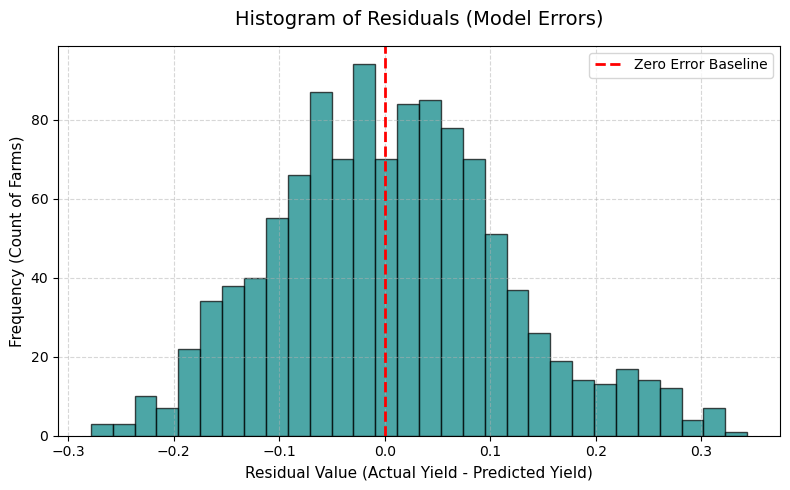

In [59]:
residuals = y_test - predictions_test # calculating the residuals
# Calculate the residuals (Test Actuals - Test Predictions)

import matplotlib.pyplot as plt

residuals = y_test - predictions_test 

# 1. Set up the plotting window size
plt.figure(figsize=(8, 5))

# 2. Plot the histogram
# bins=30 breaks the data into clean intervals; edgecolor='k' outlines the bars
plt.hist(residuals, bins=30, color='teal', edgecolor='black', alpha=0.7)

# 3. Add a vertical line at 0 to mark perfect predictions
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Baseline')

# 4. Add titles, axis labels, and a legend
plt.title('Histogram of Residuals (Model Errors)', fontsize=14, pad=15)
plt.xlabel('Residual Value (Actual Yield - Predicted Yield)', fontsize=11)
plt.ylabel('Frequency (Count of Farms)', fontsize=11)
plt.legend()

# 5. Add a subtle grid for readability
plt.grid(True, linestyle='--', alpha=0.5)

# 6. Display the plot
plt.tight_layout()
plt.show()

What does the histogram tell us about our data?

1. Examine the shape of the histogram. What does the distribution of residuals tell us about the normality of the data? Consider whether the residuals appear to be symmetrically distributed around zero.

    - ✍️
1. Shape and Normality of the Data: Looking at your plot, the distribution of the residuals forms a clear, distinct bell-shaped curve.
- Observations: The errors are heavily concentrated near the center and taper off relatively smoothly as you move outward toward the extremes ($-0.3$ and $+0.3$). This classic bell profile indicates that the residuals generally follow a normal distribution.
- What it means: Because the distribution approximates normality, it confirms that your linear regression model is fundamentally valid for this dataset. The underlying assumption that random error ($\epsilon$) is normally distributed holds up well, meaning your standard errors and any upcoming significance tests (p-values) can be trusted.
- ✍️ 
2. Compare the tails of the histogram to a normal distribution. Are there signs of heavy tails or skewness that could affect the reliability of the regression model's predictions?

3. Symmetry and the Zero Line

- When you evaluate how the data balances around the red dashed Zero Error Baseline, you can spot some minor, interesting deviations
- Observations: The residuals are mostly symmetric, but there is a slight, noticeable imbalance. The highest peak of your histogram actually occurs just to the left of the zero line (around -0.05 to -0.03). Additionally, if you look at the far right side of the plot, the tail stretches out a bit further towards +0.3, showing a small cluster of bars between 0.2 and 0.3 that isn't mirrored as strongly on the negative side.
- What it means: The peak being slightly left of zero implies that for the largest cluster of farms, the model is slightly overestimating the crop yield (\text{Actual} - \text{Predicted} < 0). Conversely, the longer right tail indicates a slight positive skewness. This means there are a handful of exceptional outlier farms where the actual yield was significantly higher than what your pollution model predicted.

    

5. Assess the centering of the histogram around the zero line. How does this central tendency reflect on the bias of the model's predictions?

    - ✍️
    - Normality & Distribution: The residuals show a healthy, bell-shaped distribution, confirming that the normality assumption required for linear regression is generally satisfied.Symmetry & Bias: The distribution is mostly symmetric around zero, indicating that the model's errors are largely balanced. However, a slight positive skew (the longer tail stretching to +0.3) and a peak slightly to the left of the baseline suggest the model occasionally overestimates standard yields, while being blindsided by a few high-performing outlier farms whose success cannot be explained by pollution levels alone.
    - Centering and Bias: The histogram's peak is shifted slightly to the left of the zero line, indicating a minor structural bias where the model most frequently overestimates standard crop yields. However, because OLS regression mathematically forces the net total of all errors to equal zero, this frequent overestimation is balanced out by the long right tail of underpredicted, high-yielding outlier farms.

Now, let's create a scatter plot of these residuals against the predicted values. 

**⚙️ Your task:**

1. Create a scatter plot of the residuals against the predicted values – `predictions_test` should be on the x-axis and the `residuals` on the y-axis.

**Note:**

- A horizontal line can be added at y=0 to make it easier to see if the residuals are evenly distributed around zero by adding this line of code:
`plt.axhline(y=0, color='r', linestyle='--')`


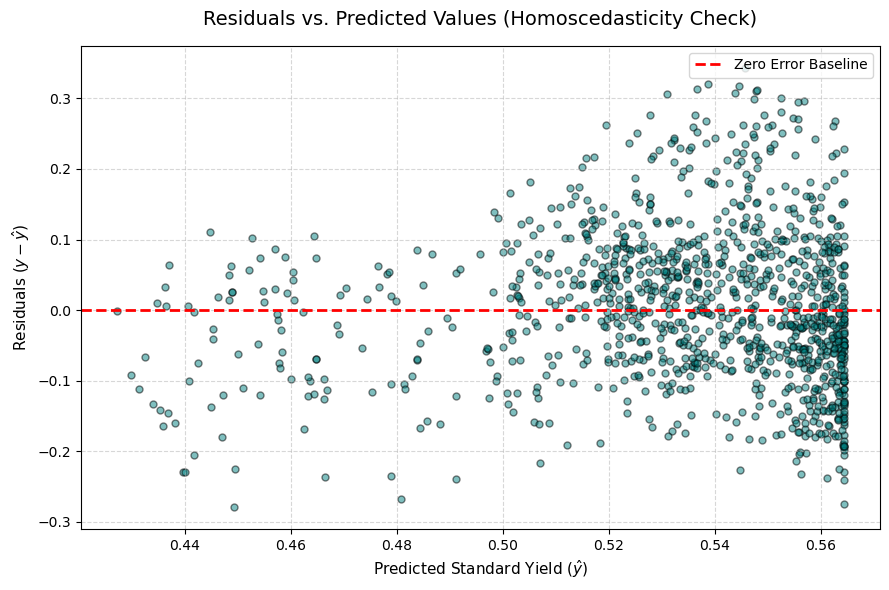

In [61]:
#  Add code to create a scatter plot of residuals against the predicted values
import matplotlib.pyplot as plt

# 1. Set up the plotting window size
plt.figure(figsize=(9, 6))

# 2. Create the scatter plot
# alpha=0.5 makes overlapping points semi-transparent to reveal data density
plt.scatter(predictions_test, residuals, color='teal', edgecolor='k', alpha=0.5, s=25)

# 3. Add the horizontal zero-error baseline
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error Baseline')

# 4. Add labels and titles
plt.title('Residuals vs. Predicted Values (Homoscedasticity Check)', fontsize=14, pad=15)
plt.xlabel('Predicted Standard Yield ($\hat{y}$)', fontsize=11)
plt.ylabel('Residuals ($y - \hat{y}$)', fontsize=11)
plt.legend(loc='upper right')

# 5. Add a subtle grid for alignment verification
plt.grid(True, linestyle='--', alpha=0.5)

# 6. Display the plot
plt.tight_layout()
plt.show()

Reflect on what the scatter plot tells us about our data and the fit of the model:

1. Analyse the scatter plot for any apparent patterns or structures in the data. What does this suggest about the appropriateness of the linear regression model for the dataset?

    - ✍️ 
- Patterns, Structure, and Model AppropriatenessAnalysis:
- The scatter plot displays a highly distinct structure rather than a random cloud of points. The data points abruptly stop and stack up vertically along a hard wall on the right side of the graph—right at a predicted yield of approximately $0.565$. As you move from left to right, the density of the data points increases dramatically.Implication: This vertical "wall" represents the absolute maximum prediction limit of your model.
- Since the model's equation is $\hat{y} = \text{Intercept} + (\text{Slope} \times \text{Pollution})$, and pollution levels cannot drop below $0$, the model can never predict a yield higher than its y-intercept value ($\approx 0.5663$). This structural boundary proves that a simple linear regression model using only pollution is highly inadequate. It cannot naturally capture the real ceiling or floor dynamics of farm yields.

2. Inspect the plot for signs of heteroscedasticity. How does the spread of residuals change as the predicted values increase? What might this imply about the constant variance assumption in linear regression?

    - ✍️
- Heteroscedasticity and Constant VarianceAnalysis:
- There is severe, undeniable heteroscedasticity present in this plot.On the left side (lower predicted yields, which correspond to farms with high pollution), the vertical spread of the residuals is relatively tight (ranging roughly from $-0.2$ to $+0.1$).On the right side (higher predicted yields, corresponding to pristine, low-pollution farms), the vertical spread erupts significantly, spanning all the way from $-0.3$ to $+0.35$.
- Implication: The variance of your errors is not constant; it forms a horizontal funnel shape that fans out as predictions increase. This violates the assumption of homoscedasticity. It tells you that when pollution is high, the model's predictions are relatively constrained.
- However, when pollution is low, crop yields become wildly volatile and unpredictable. This makes sense practically: if a farm isn't polluted, its actual yield could be amazing or terrible depending entirely on other missing factors like rain, pests, or soil nutrients.

3. Identify whether the residuals are evenly scattered above and below the zero line across the range of predicted values. What can this tell us about the model's performance in terms of bias and prediction accuracy?

    - ✍️ 
- Distribution Around the Zero Line (Bias & Accuracy)
- Analysis: The residuals are not evenly distributed around the red dashed zero line across the prediction spectrum.Between predicted values of $0.42$ and $0.50$, more points sink below the line than sit above it.Near the right-hand wall ($0.52$ to $0.56$), the points explode in both directions, but a noticeable cluster of points stretches high into positive territory ($+0.2$ to $+0.35$).
- Implication: This uneven scattering indicates local prediction bias. When predicting low yields (high pollution areas), the model is systematically overestimating actual performance (producing negative residuals). On the flip side, near the baseline intercept, the model experiences its worst prediction accuracy, missing actual yields by massive margins because it completely lacks the additional data features required to explain why some clean farms thrived while others failed.

4. Look for outliers or clusters of points that deviate significantly from the majority. How might these points influence the overall fit of the model?

    - ✍️ 
- Outliers and Clusters
- Analysis: The most critical cluster is the dense vertical column of points slammed against the maximum prediction boundary on the far right. Within this cluster, there are several extreme positive outliers shooting above $+0.25$ and $+0.3$.
- Implication: These high-flying points represent "super-farms"—locations with minimal pollution that achieved massive, maximum-scale yields. Because the ordinary least squares algorithm works by minimizing squared errors, these distant outliers pull upward on the right side of your regression line like a lever. This forces the slope to adapt to them, which inadvertently compromises the model's prediction accuracy for the normal, average farms on the left side of the chart.

Summary 
- Appropriateness: Poor. The hard vertical ceiling at $\hat{y} \approx 0.565$ shows a single-variable straight line cannot model agricultural limits cleanly.
- Variance: Strongly heteroscedastic. The error variance expands significantly as predicted yield increases, meaning our model loses its reliability in low-pollution regions.
- Verdict: This plot serves as a definitive green light to abandon simple linear regression and upgrade to Multiple Linear Regression, allowing other features to break this artificial prediction wall and resolve the expanding variance.

Our final task is to examine the mean and standard deviation of the residuals, which provide further insights into the model's performance.

**⚙️ Your task:**

Create a function named `calculate_residuals_statistics` that:
1. Uses the `predictions_test` and `y_test` (obtained from Challenge 4) to calculate the residuals.
2. Calculates the mean and standard deviation of the residuals.

**Note:**

- Use `numpy` for the mean and standard deviation.

In [7]:
import numpy as np

In [65]:
### START FUNCTION

def calculate_residuals_statistics(predictions, y_test):
    """
    Calculates the mean and standard deviation of the model's residuals.
    
    Parameters:
    predictions (np.ndarray): The predicted target values from the test split.
    y_test (pd.Series or np.ndarray): The actual target values from the test split.
    
    Returns:
    tuple: A tuple containing (mean_residual, std_residual) as floats.
    """
    # 1. Calculate the residuals
    residuals = y_test - predictions
    
    # 2. Calculate the mean of the residuals
    mean_residual = float(np.mean(residuals))
    
    # 3. Calculate the standard deviation of the residuals
    std_residual = float(np.std(residuals))
    
    return mean_residual, std_residual
   
### END FUNCTION

Input:

In [66]:
mean_residual, std_residual = calculate_residuals_statistics(predictions_test, y_test)
print(f"Mean: {mean_residual}\nStandard deviation: {std_residual}")

Mean: 0.00585802319232171
Standard deviation: 0.11052745268770955


Expected output: 
```
Mean: 0.0058580231923217015
Standard deviation: 0.11052745268770957
```

What does the mean of the residuals tell us about the bias in our predictions? How does a mean close to zero reflect on our model's accuracy?

- ✍️ 
1. The Mean of the Residuals and Prediction Bias
- The Meaning: Your calculated mean of 0.0058 is exceptionally close to 0. In the context of an ordinary least squares (OLS) regression model, a mean close to zero indicates that the model is globally unbiased. It means that the total sum of your overestimations (negative residuals) almost perfectly cancels out the total sum of your underestimations (positive residuals) across the 1,131 test farms.
- Reflecting on Accuracy: It is vital to note that a mean near zero does not mean your model is highly accurate. It only means the model is balanced on average. As you saw in your scatter plot, individual predictions are still missing the actual target by significant margins. A model can be completely wrong on every single farm, but if it overestimates by +0.2 on half the farms and underestimates by -0.2 on the other half, the mean residual will still be exactly 0. Therefore, the mean tells us about the direction of systemic bias (or lack thereof), not the closeness of individual predictions.

What does the standard deviation of the residuals indicate about the variability of our predictions? Why is it important for this value to be relatively low?

 - ✍️ 
2. Standard Deviation and Prediction Variability
- The Meaning: The standard deviation of your residuals (0.1105) measures the spread, or the typical "scatter," of your errors. Assuming a normal distribution, this number tells you that roughly 68% of your model's predictions miss the actual crop yield by \pm 0.1105 units or less.
- Why Low Variability Matters: It is crucial for this value to be as low as possible because it represents the precision of your model. A low standard deviation means that the data points hug your regression line tightly. In agriculture and predictive modeling, low variability means consistency; it implies that the model's errors are small and tightly bounded, allowing you to trust that any single prediction you make isn't going to be wildly far from reality.

What are the potential consequences of a high standard deviation of residuals on the reliability of the model's predictions? How might this affect our confidence in the model's estimates?

- ✍️ 
3. The Impact on Confidence:
- If this value shifts higher, your confidence intervals for any given prediction widen dramatically. For instance, if a farmer asks you to estimate their standardized yield and your model predicts 0.55, a high standard deviation means the actual yield could easily turn out to be 0.25 or 0.85.
- This completely destroys the practical utility of the model. You cannot confidently use the model's estimates for risk management, supply chain planning, or financial forecasting because the margin of error is too wide to make safe business decisions.

## Conclusion

Linear regression, for all its strengths, assumes a straightforward relationship between the predictor and the outcome. Yet, the natural world seldom adheres to such simplicity. Factors influencing crop yields be it temperature, rainfall, or pollution – interact in complex, often nonlinear ways. Our initial model with `Ave_temps` hinted at this complexity, suggesting that the effect of the average temperature on yields might follow a more intricate pattern than a straight line can depict (or no pattern at all).

Our yield also depends on more than just the pollution or the temperature; it depends on many of the factors – we could see that from our EDA. We also saw that not all crops are affected equally by pollution or temperature, so we could simplify our model if we remove the influence of the different crops.

As we dive deeper into regression, it's crucial to remember that with each model comes a new perspective. Just as a farmer selects the tool that best suits the task at hand, so we must choose our models with intention and insight. Exploring beyond linear regression opens up new vistas of understanding, allowing us to capture the richness of relationships within our data.

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="COPYRIGHT_MIKE_BWISA_MWASAME-01.jpg"  style="width:200px; width:100%;"/>
</div>